# Credit Card Fraud Detection
## CODSOFT Data Science Internship - Task 5

**Student Name:** Jenil Bhisra  
**Internship:** CODSOFT  
**Domain:** Data Science  
**Task Number:** 5  
**Project Type:** Machine Learning Classification

---

This notebook builds a machine learning model to detect fraudulent credit card transactions. The goal is to classify transactions as **genuine** or **fraudulent** using transaction features.

## 1. Project Objective

Credit card fraud detection is an important real-world machine learning problem. Banks and payment companies need to identify suspicious transactions quickly so that customers can be protected from financial loss.

In this project, we will:

- Load and understand the credit card transaction dataset.
- Perform data cleaning and exploratory data analysis.
- Normalize numerical transaction features.
- Handle the highly imbalanced dataset problem.
- Train classification models to detect fraud.
- Evaluate the models using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix.

This is a **binary classification** problem because the target column has two classes:

- `0` = Genuine Transaction
- `1` = Fraudulent Transaction

In [50]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

## 2. Load the Dataset

The dataset file used in this notebook is `creditcard.csv`. It contains credit card transaction records with anonymized numerical features.

Most feature columns are named `V1` to `V28` because the original transaction details were transformed for privacy reasons. The main understandable columns are:

- `Time`: Time elapsed from the first transaction.
- `Amount`: Transaction amount.
- `Class`: Target variable where `0` means genuine and `1` means fraud.

In [51]:
# Load dataset
file_path = 'creditcard.csv'
df = pd.read_csv(file_path)

# Display first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [52]:
# Dataset shape
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])

Number of rows: 284807
Number of columns: 31


In [53]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [54]:
# Statistical summary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Data Cleaning and Basic Checks

Before building the model, we need to check whether the dataset contains missing values or duplicate records.

In [55]:
# Check missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [56]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 1081


In [57]:
# Remove duplicate rows if present
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]
print('Rows before removing duplicates:', before_rows)
print('Rows after removing duplicates:', after_rows)
print('Removed rows:', before_rows - after_rows)

Rows before removing duplicates: 284807
Rows after removing duplicates: 283726
Removed rows: 1081


### Observation

- The dataset does not contain missing values.
- Duplicate transactions, if present, were removed to make the dataset cleaner.
- The target column is `Class`, where fraud transactions are usually very rare compared to genuine transactions.

## 4. Exploratory Data Analysis (EDA)

EDA helps us understand the data distribution and the relationship between features and the target variable.

In [58]:
# Count genuine and fraud transactions
class_counts = df['Class'].value_counts().sort_index()
class_percent = df['Class'].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    'Class': ['Genuine (0)', 'Fraud (1)'],
    'Count': class_counts.values,
    'Percentage': class_percent.values
})
class_summary

,Class,Count,Percentage
0,Genuine (0),283253,99.83329
1,Fraud (1),473,0.16671


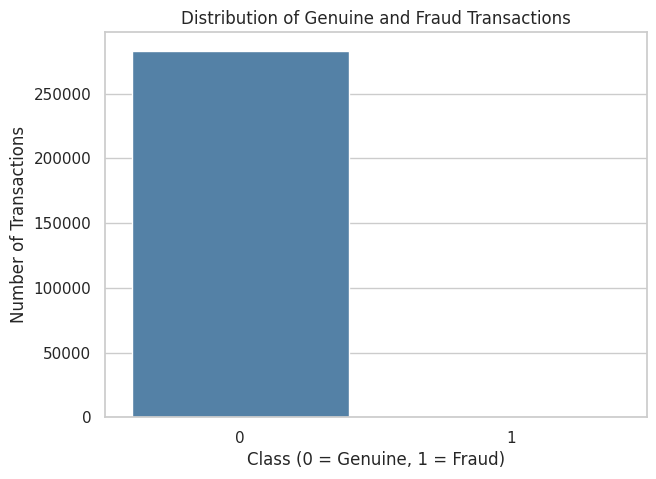

In [59]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Class', color='steelblue')
plt.title('Distribution of Genuine and Fraud Transactions')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

### Observation

The dataset is highly imbalanced. Genuine transactions are much more common than fraudulent transactions. Because of this, accuracy alone is not enough to judge model performance. We must also check **precision, recall, F1-score**, and **ROC-AUC**.

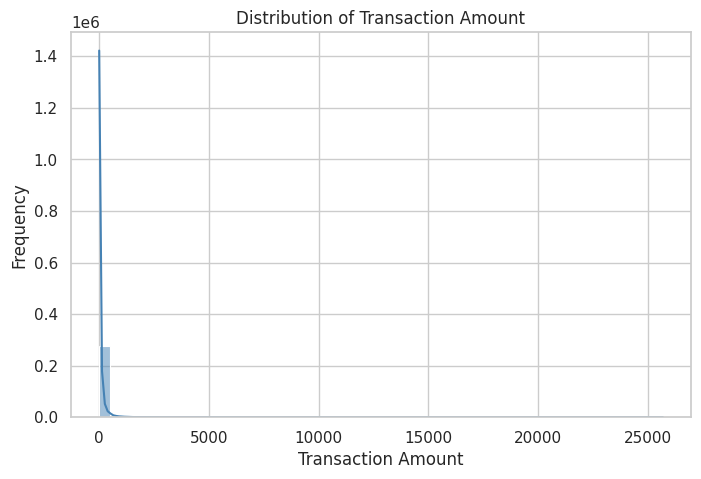

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

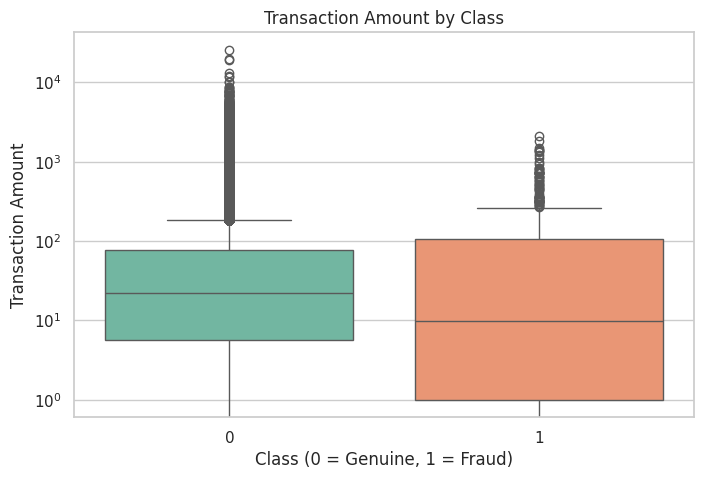

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Class', y='Amount', palette='Set2')
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.yscale('log')
plt.show()

### Observation

Transaction amount has a wide range, and some transactions are much larger than others. Scaling the `Amount` column is important because machine learning models can be affected by differences in feature scale.

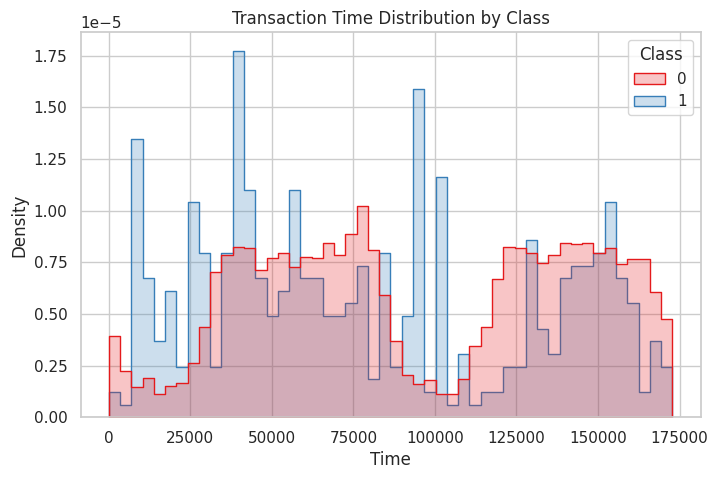

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Time', hue='Class', bins=50, element='step', stat='density', common_norm=False, palette='Set1')
plt.title('Transaction Time Distribution by Class')
plt.xlabel('Time')
plt.ylabel('Density')
plt.show()

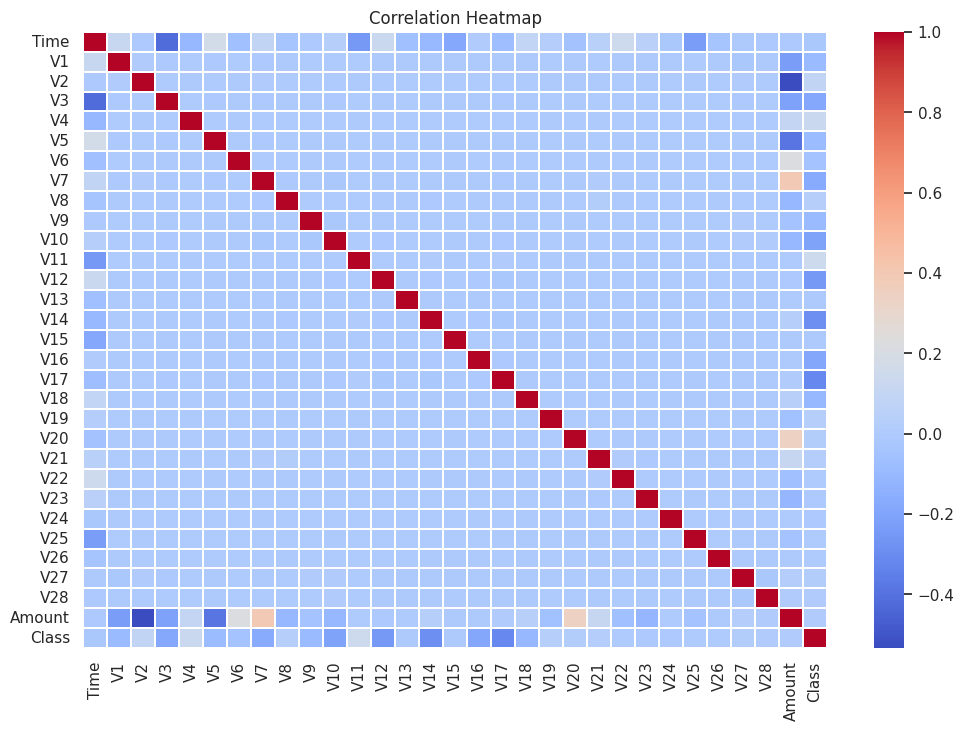

In [63]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.2)
plt.title('Correlation Heatmap')
plt.show()

In [64]:
# Features most correlated with target Class
corr_with_class = df.corr()['Class'].sort_values(ascending=False)
corr_with_class.head(10)

,Class
Class,1.000000
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682


In [65]:
corr_with_class.tail(10)

,Class
V9,-0.094021
V1,-0.094486
V18,-0.105340
V7,-0.172347
V3,-0.182322
V16,-0.187186
V10,-0.206971
V12,-0.250711
V14,-0.293375
V17,-0.313498


### Observation

Some anonymized features show stronger positive or negative correlation with fraud. These features can help the model separate genuine and fraudulent transactions.

## 5. Feature Scaling

The `Amount` and `Time` columns have values on different scales. We will standardize them using `StandardScaler`.

Scaling is especially useful for algorithms such as Logistic Regression.

In [66]:
# Create a copy for preprocessing
data = df.copy()

scaler = StandardScaler()
data['Scaled_Amount'] = scaler.fit_transform(data[['Amount']])
data['Scaled_Time'] = scaler.fit_transform(data[['Time']])

# Drop original Amount and Time columns after scaling
data = data.drop(['Amount', 'Time'], axis=1)

# Reorder columns for readability
cols = ['Scaled_Time', 'Scaled_Amount'] + [col for col in data.columns if col not in ['Scaled_Time', 'Scaled_Amount', 'Class']] + ['Class']
data = data[cols]

data.head()

,Scaled_Time,Scaled_Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-1.996823,0.244200,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-1.996823,-0.342584,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,-1.996802,1.158900,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,-1.996802,0.139886,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-1.996781,-0.073813,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## 6. Split Features and Target

Here:

- `X` contains independent features.
- `y` contains the target variable `Class`.

In [67]:
# Drop any rows with missing values to ensure clean training
data = data.dropna()

X = data.drop('Class', axis=1)
y = data['Class']

print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Feature shape: (283726, 30)
Target shape: (283726,)


In [68]:
# Ensuring the target variable is consistent and clean after handling missing values
# We confirm the class distribution in the split data
if 'y_train' in globals():
    print('Target variable consistency confirmed.')
    print(y_train.value_counts())
else:
    print('Data split not yet performed. Please run cell 4655b341 to split the data.')

Target variable consistency confirmed.
Class
0.0    14224
1.0       65
Name: count, dtype: int64


In [69]:
# Train-test split with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)
print('\nTraining class distribution:')
print(y_train.value_counts())
print('\nTesting class distribution:')
print(y_test.value_counts())

Training set: (226980, 30)
Testing set: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


## 7. Handling Class Imbalance Using Undersampling

Credit card fraud datasets are highly imbalanced. If we train directly on the original data, the model may become biased toward the genuine class.

To handle this, we will use **random undersampling** on the training data:

- Keep all fraud transactions.
- Randomly select the same number of genuine transactions.
- Train models on this balanced training dataset.

Important: We only balance the training data. The test data remains unchanged so that evaluation is realistic.

In [70]:
# Combine training data for undersampling
train_data = pd.concat([X_train, y_train], axis=1)

fraud_train = train_data[train_data['Class'] == 1]
genuine_train = train_data[train_data['Class'] == 0]

genuine_sample = genuine_train.sample(n=len(fraud_train), random_state=42)
balanced_train = pd.concat([fraud_train, genuine_sample], axis=0).sample(frac=1, random_state=42)

X_train_balanced = balanced_train.drop('Class', axis=1)
y_train_balanced = balanced_train['Class']

print('Balanced training class distribution:')
print(y_train_balanced.value_counts())

Balanced training class distribution:
Class
0    378
1    378
Name: count, dtype: int64


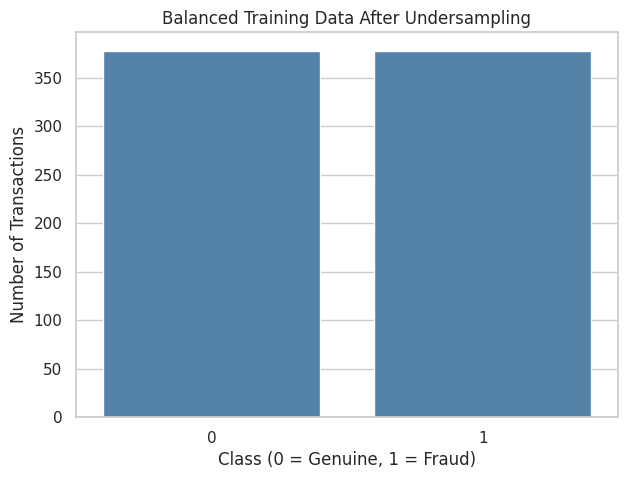

In [71]:
plt.figure(figsize=(7,5))
sns.countplot(x=y_train_balanced.values, color='steelblue')
plt.title('Balanced Training Data After Undersampling')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

## 8. Model Training

We will train three classification models:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

Since fraud detection is sensitive, we will focus strongly on **recall** and **F1-score** along with accuracy.

In [72]:
# Function to train and evaluate models
def evaluate_model(model_name, model, X_train_data, y_train_data, X_test_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_prob)
    else:
        roc_auc = np.nan

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_data, y_pred),
        'Precision': precision_score(y_test_data, y_pred),
        'Recall': recall_score(y_test_data, y_pred),
        'F1 Score': f1_score(y_test_data, y_pred),
        'ROC-AUC': roc_auc
    }

    return results, y_pred

In [73]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
}

model_results = []
predictions = {}

for name, model in models.items():
    # Use the evaluation function defined in cell 4b13fb08
    result, y_pred = evaluate_model(name, model, X_train_balanced, y_train_balanced, X_test, y_test)
    model_results.append(result)
    predictions[name] = y_pred

results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973108,0.051972,0.873684,0.098109,0.955867
1,Decision Tree,0.932982,0.021672,0.884211,0.042307,0.945799
2,Random Forest,0.988387,0.110497,0.842105,0.195360,0.970586


## 9. Model Comparison

Now we compare the trained models using multiple evaluation metrics.

In [74]:
# Show results sorted by F1 Score
results_df_sorted = results_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
results_df_sorted

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.988387,0.110497,0.842105,0.195360,0.970586
1,Logistic Regression,0.973108,0.051972,0.873684,0.098109,0.955867
2,Decision Tree,0.932982,0.021672,0.884211,0.042307,0.945799


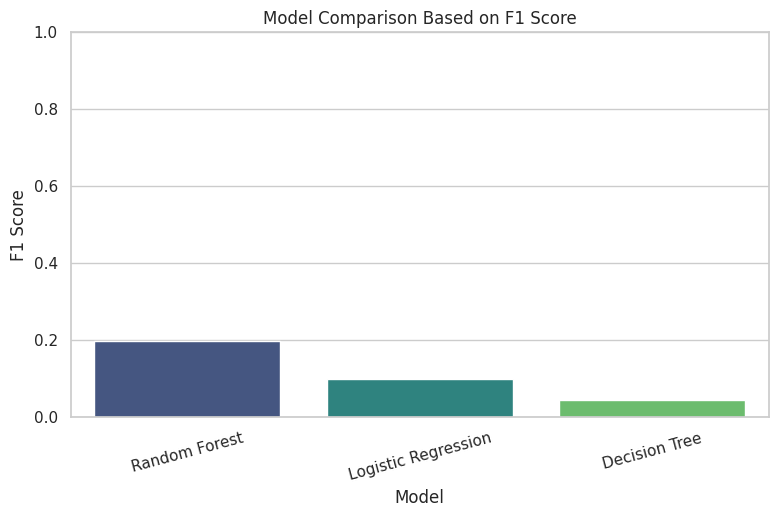

In [75]:
# Visualization of model comparison
if 'results_df_sorted' in globals():
    plt.figure(figsize=(9,5))
    sns.barplot(data=results_df_sorted, x='Model', y='F1 Score', palette='viridis')
    plt.title('Model Comparison Based on F1 Score')
    plt.xlabel('Model')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.show()
else:
    print('Results not available. Please run the model training cells first.')

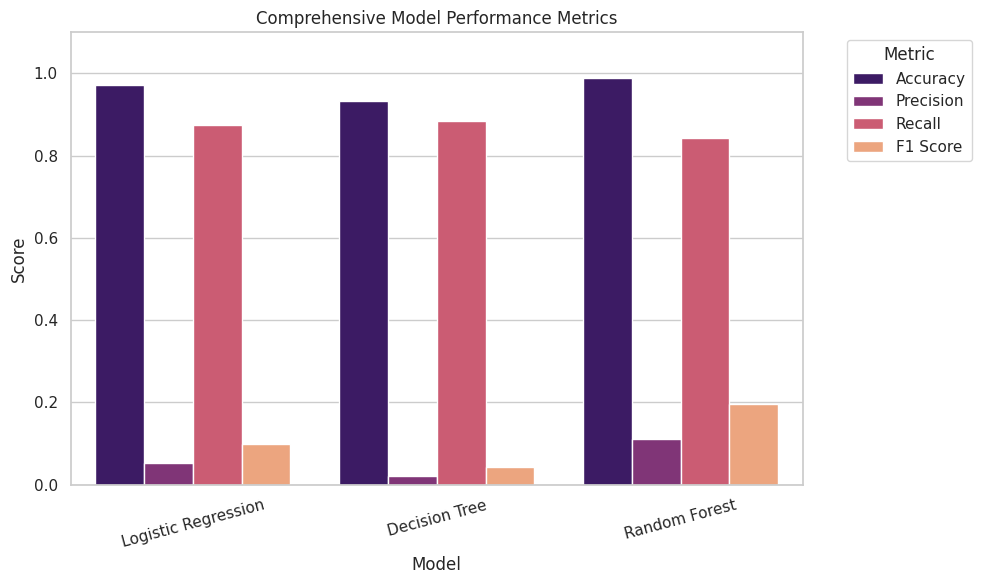

In [76]:
# Comprehensive metric comparison
if 'results_df' in globals():
    plt.figure(figsize=(10,6))
    comparison_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'])
    sns.barplot(data=comparison_melted, x='Model', y='value', hue='variable', palette='magma')
    plt.title('Comprehensive Model Performance Metrics')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.xticks(rotation=15)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Results dataframe not found. Please execute model training.')

## 10. Best Model Selection

The best model is selected based on F1-score because F1-score balances precision and recall. In fraud detection, both are important:

- **Precision** tells how many predicted fraud cases were actually fraud.
- **Recall** tells how many actual fraud cases were successfully detected.
- **F1-score** balances both precision and recall.

In [77]:
best_model_name = results_df_sorted.iloc[0]['Model']
best_model = models[best_model_name]
best_predictions = predictions[best_model_name]

print('Best Model:', best_model_name)
print('Best F1 Score:', results_df_sorted.iloc[0]['F1 Score'])

Best Model: Random Forest
Best F1 Score: 0.19536019536019536


## 11. Confusion Matrix for Best Model

A confusion matrix shows the correct and incorrect predictions made by the model.

For fraud detection:

- **True Negative (TN):** Genuine transaction correctly predicted as genuine.
- **False Positive (FP):** Genuine transaction incorrectly predicted as fraud.
- **False Negative (FN):** Fraud transaction incorrectly predicted as genuine.
- **True Positive (TP):** Fraud transaction correctly predicted as fraud.

False negatives are very important because a fraudulent transaction missed by the model can cause financial loss.

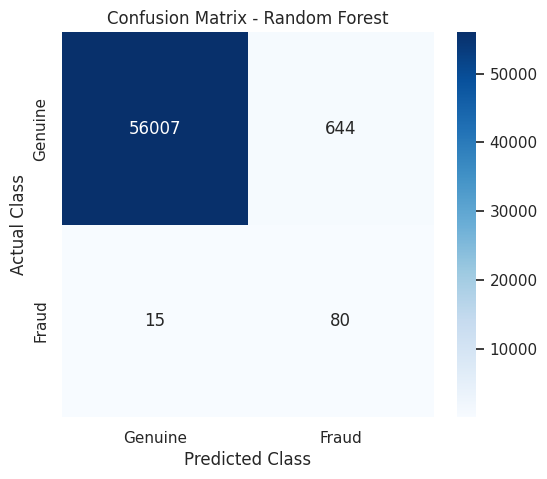

Confusion Matrix Values:
[[56007   644]
 [   15    80]]


In [78]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fraud'],
            yticklabels=['Genuine', 'Fraud'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

print('Confusion Matrix Values:')
print(cm)

## 12. Classification Report

The classification report gives precision, recall, F1-score, and support for both classes.

In [79]:
print('Classification Report for', best_model_name)
print(classification_report(y_test, best_predictions, target_names=['Genuine', 'Fraud']))

Classification Report for Random Forest
              precision    recall  f1-score   support

     Genuine       1.00      0.99      0.99     56651
       Fraud       0.11      0.84      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.59     56746
weighted avg       1.00      0.99      0.99     56746



## 13. Sample Prediction

Now we will test the best model on one sample transaction from the dataset.

In [80]:
# Select a sample transaction from test data
sample_transaction = X_test.iloc[[0]]
actual_class = y_test.iloc[0]

sample_prediction = best_model.predict(sample_transaction)[0]

print('Actual Class:', 'Fraud' if actual_class == 1 else 'Genuine')
print('Predicted Class:', 'Fraud' if sample_prediction == 1 else 'Genuine')

if sample_prediction == actual_class:
    print('Result: The model correctly identified this transaction.')
else:
    print('Result: The model misclassified this transaction.')

Actual Class: Genuine
Predicted Class: Genuine
Result: The model correctly identified this transaction.


## 14. Final Conclusion

- The credit card fraud detection dataset was successfully loaded and analyzed.
- The dataset contained anonymized transaction features and a binary target column named `Class`.
- Missing value checks and duplicate checks were performed during data cleaning.
- Exploratory Data Analysis showed that the dataset is highly imbalanced.
- The `Amount` and `Time` columns were normalized using `StandardScaler`.
- Random undersampling was applied to the training data to handle class imbalance.
- Three classification models were trained: Logistic Regression, Decision Tree, and Random Forest.
- The models were compared using accuracy, precision, recall, F1-score, and ROC-AUC.
- The best model was selected based on F1-score because fraud detection requires a balance between precision and recall.
- The final model can classify credit card transactions as genuine or fraudulent.
